# Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on stock data.

In [1]:
%pip install python-dotenv --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install seaborn --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install python-dotenv --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from src.data_collection.load_kaggle_data import load_kaggle_data, load_all_tickers
from src.preprocessing.clean_data import clean_ohlcv_data
from src.utils.data_split import split_data_by_date
from src.utils.config import DEFAULT_TICKERS

## Load Data

In [ ]:
# Load all Kaggle data
print("Loading Kaggle data for all tickers...")
all_data = load_all_tickers()

print(f"\nLoaded {len(all_data)} tickers:")
for ticker, df in all_data.items():
    start_date, end_date = df.index[0], df.index[-1]
    print(f"  {ticker:<25} | {len(df):>10} rows | {start_date.date()} to {end_date.date()}")

# Use first ticker for exploration
ticker = DEFAULT_TICKERS[0]
raw_data = all_data[ticker]
print(f"\n{'='*60}")
print(f"Exploring: {ticker}")
print(f"{'='*60}")

Using ticker: RELIANCE.NS


1D Data:
  File: RELIANCE.NS.csv
  Shape: (1227, 5)
  Date Range: Ticker to 2024-12-11
  Preview:
                        Close               High                Low  \
Price                                                                 
Ticker            RELIANCE.NS        RELIANCE.NS        RELIANCE.NS   
Date                      NaN                NaN                NaN   
2020-01-01       675.32421875  683.1529137163456   673.490123328754   
2020-01-02  686.8212280273438  689.3487905881979   676.397899264457   
2020-01-03  687.6488037109375  689.6618949086101  681.3187290426969   

                         Open       Volume  
Price                                       
Ticker            RELIANCE.NS  RELIANCE.NS  
Date                      NaN          NaN  
2020-01-01  679.0819971118469     14004468  
2020-01-02   676.397899264457     17710316  
2020-01-03  685.7922517653002     20984698  

5M Data:
  File: RELIANCE.NS_5m.csv
  Shape: (1652, 5)
  Dat

C:\Users\Sunay Bhattacharjee\AppData\Local\Temp\ipykernel_14264\2265374507.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_intervals[interval] = pd.read_csv(data_path, index_col=0, parse_dates=True)
C:\Users\Sunay Bhattacharjee\AppData\Local\Temp\ipykernel_14264\2265374507.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_intervals[interval] = pd.read_csv(data_path, index_col=0, parse_dates=True)
C:\Users\Sunay Bhattacharjee\AppData\Local\Temp\ipykernel_14264\2265374507.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_intervals[interval] = pd.read

### Data Distribution (Raw vs Cleaned)

In [ ]:
print(f"Raw Data Shape: {raw_data.shape}")
print(f"Raw Data Info:")
print(raw_data.describe())

# Clean the data
cleaned_data = clean_ohlcv_data(raw_data)
print(f"\n{'='*60}")
print(f"Cleaned Data Shape: {cleaned_data.shape}")
print(f"Cleaned Data Info:")
print(cleaned_data.describe())

Available data files:
✓ RELIANCE.NS.csv
✓ RELIANCE.NS_5m.csv
✓ RELIANCE.NS_1m.csv
✓ TCS.NS.csv
✓ TCS.NS_5m.csv
✓ TCS.NS_1m.csv
✓ INFY.NS.csv
✓ INFY.NS_5m.csv
✓ INFY.NS_1m.csv
✓ HDFCBANK.NS.csv
✓ HDFCBANK.NS_5m.csv
✓ HDFCBANK.NS_1m.csv
✓ ICICIBANK.NS.csv
✓ ICICIBANK.NS_5m.csv
✓ ICICIBANK.NS_1m.csv


## Basic Statistics

In [9]:
# Ensure `data` variable exists: prefer 1d, then 5m, then 1m
if '1d' in data_intervals:
    data = data_intervals['1d']
elif '5m' in data_intervals:
    data = data_intervals['5m']
elif '1m' in data_intervals:
    data = data_intervals['1m']
else:
    raise NameError('No interval data loaded; run the Load Data cell first')

# Show basic stats for the selected dataframe
data.describe()

,Close,High,Low,Open,Volume
count,1226,1226,1226,1226,1226
unique,1210,1226,1226,1226,1226
top,866.5751953125,1284.8683422637005,1270.9738844056644,1279.8882324099652,11724373
freq,2,1,1,1,1


## Price Trends

In [ ]:
# Split data by dates (2015-2023 train, 2024 test)
train_data, test_data = split_data_by_date(cleaned_data)

print(f"Training Period (2015-2023): {len(train_data)} rows")
print(f"  Start: {train_data.index[0]}")
print(f"  End:   {train_data.index[-1]}")
print(f"\nTest Period (2024): {len(test_data)} rows")
print(f"  Start: {test_data.index[0]}")
print(f"  End:   {test_data.index[-1]}")

# Statistics by period
print(f"\n{'='*60}")
print("Training Data Statistics:")
print(train_data[['Close', 'Volume']].describe())

print(f"\n{'='*60}")
print("Test Data Statistics:")
print(test_data[['Close', 'Volume']].describe())

data type: <class 'pandas.core.frame.DataFrame'>
columns: ['Close', 'High', 'Low', 'Open', 'Volume']
index dtype: object
                        Close               High                Low  \
Price                                                                 
Ticker            RELIANCE.NS        RELIANCE.NS        RELIANCE.NS   
Date                      NaN                NaN                NaN   
2020-01-01       675.32421875  683.1529137163456   673.490123328754   
2020-01-02  686.8212280273438  689.3487905881979   676.397899264457   
2020-01-03  687.6488037109375  689.6618949086101  681.3187290426969   

                         Open       Volume  
Price                                       
Ticker            RELIANCE.NS  RELIANCE.NS  
Date                      NaN          NaN  
2020-01-01  679.0819971118469     14004468  
2020-01-02   676.397899264457     17710316  
2020-01-03  685.7922517653002     20984698  
'Close' dtype after coercion: float64
'Close' NaNs: 2
'Volume' dty

C:\Users\Sunay Bhattacharjee\AppData\Local\Temp\ipykernel_14264\2236103919.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data.index = pd.to_datetime(data.index)


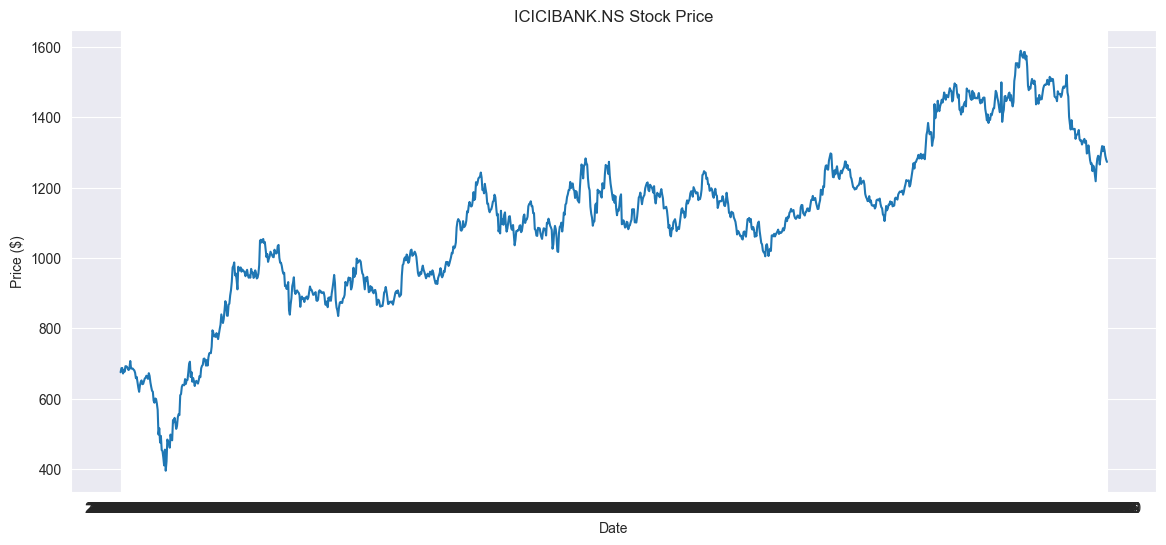

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Close price over time
axes[0, 0].plot(cleaned_data.index, cleaned_data['Close'])
axes[0, 0].axvline(x=pd.Timestamp('2024-01-01'), color='r', linestyle='--', label='Train/Test Split')
axes[0, 0].set_title('Close Price Over Time')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price')
axes[0, 0].legend()

# Volume over time
axes[0, 1].bar(cleaned_data.index, cleaned_data['Volume'], width=0.01)
axes[0, 1].axvline(x=pd.Timestamp('2024-01-01'), color='r', linestyle='--', label='Train/Test Split')
axes[0, 1].set_title('Volume Over Time')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Volume')
axes[0, 1].legend()

# Price distribution
axes[1, 0].hist(train_data['Close'], bins=50, alpha=0.5, label='Train (2015-2023)')
axes[1, 0].hist(test_data['Close'], bins=50, alpha=0.5, label='Test (2024)')
axes[1, 0].set_title('Price Distribution')
axes[1, 0].set_xlabel('Close Price')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# Returns distribution
train_returns = train_data['Close'].pct_change().dropna()
test_returns = test_data['Close'].pct_change().dropna()
axes[1, 1].hist(train_returns, bins=50, alpha=0.5, label='Train (2015-2023)')
axes[1, 1].hist(test_returns, bins=50, alpha=0.5, label='Test (2024)')
axes[1, 1].set_title('Returns Distribution')
axes[1, 1].set_xlabel('Returns')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## Volume Analysis

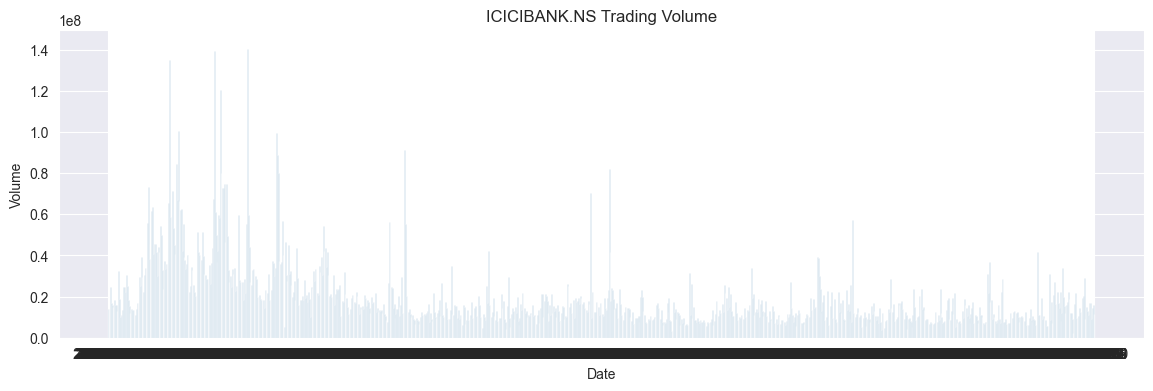

In [ ]:
# Price range per year
yearly_stats = cleaned_data.groupby(cleaned_data.index.year)['Close'].agg(['min', 'max', 'mean'])
print("Yearly Price Statistics:")
print(yearly_stats)

fig, ax = plt.subplots(figsize=(12, 5))
years = yearly_stats.index
ax.fill_between(years, yearly_stats['min'], yearly_stats['max'], alpha=0.3, label='Min-Max Range')
ax.plot(years, yearly_stats['mean'], marker='o', linewidth=2, markersize=6, label='Mean Price')
ax.set_title('Yearly Price Range')
ax.set_xlabel('Year')
ax.set_ylabel('Price')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Returns Distribution

C:\Users\Sunay Bhattacharjee\AppData\Local\Temp\ipykernel_14264\231038378.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['returns'] = data['Close'].pct_change()


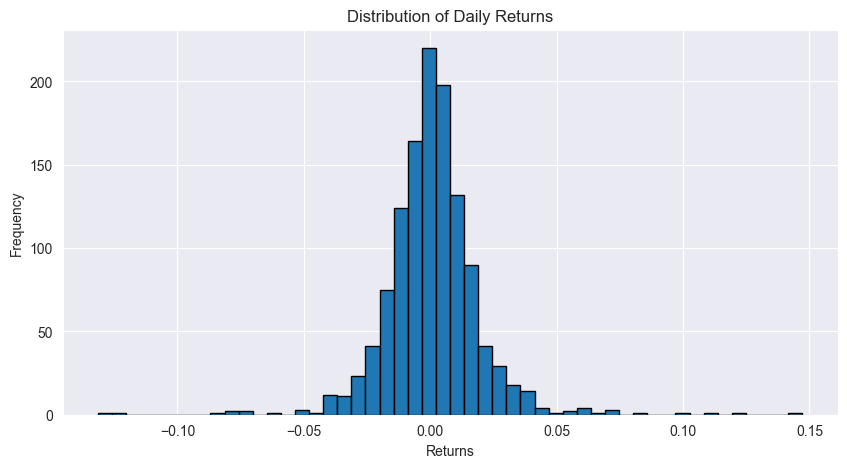

In [ ]:
# Volatility analysis
train_vol = train_data['Close'].pct_change().rolling(window=30).std()
test_vol = test_data['Close'].pct_change().rolling(window=30).std()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_vol.index, train_vol, label='Train (2015-2023)', linewidth=1)
ax.plot(test_vol.index, test_vol, label='Test (2024)', linewidth=2, color='red')
ax.axvline(x=pd.Timestamp('2024-01-01'), color='gray', linestyle='--', alpha=0.5)
ax.set_title('30-Day Rolling Volatility')
ax.set_xlabel('Date')
ax.set_ylabel('Volatility (Std of Returns)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Training Period Volatility: {train_vol.mean():.4f} (mean), {train_vol.std():.4f} (std)")
print(f"Test Period Volatility: {test_vol.mean():.4f} (mean), {test_vol.std():.4f} (std)")